# 2→2 scattering in `feynlag`: from Mandelstam invariants to a forward–backward asymmetry

*For a reader who has been through the [Particle Decays Tutorial](Particle_Decays_Tutorial.ipynb)
and knows what a Dirac trace and a spin sum are, but has never seen a **cross section**
derived — only a decay width.*

Every decay example in this library computes one particle going to two: a width
$\Gamma$. This notebook computes the other basic collider observable — two particles
**scattering** into two, a cross section $\sigma$ — starting from
$e^+e^-\to\mu^+\mu^-$ through a photon (textbook QED), and ending at
$e^+e^-\to\mu^+\mu^-$ through the **Z alone**, where something genuinely new happens:
a $\gamma_5$ (ε-tensor) term that is exactly zero in every decay this library has ever
computed turns out to be **non-zero** here. That term is the physical
forward–backward asymmetry $A_{FB}$ — a real, measured LEP observable — and getting it
requires new algebra (`feynlag.pheno.epsilon`) beyond anything the decay engine needed.

This is Tiers 1–2 of `docs/manual/scattering_roadmap.md` (chapter 17).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

from feynlag import (
    Lagrangian, Model, WeylFermion, electroweak_scaffold,
    fermion_gauge_current, to_physical_basis,
)
from feynlag.pheno import (
    ExternalState, TwoToTwoKinematics, collect_decay_vertices, cross_section,
    differential_cross_section, ffv_s_channel_squared, forward_backward_asymmetry,
)
from feynlag.pheno.epsilon import (
    epsilon_pair_tensor, epsilon_product_sign, gamma5_trace_coefficient,
    gram_determinant, levi_civita_array,
)

sp.init_printing()

Missing colon in file PosixPath('/home/moises/.config/matplotlib/stylelib/ifunam.mplstyle'), line 28 ("    '003DA5',")


Missing colon in file PosixPath('/home/moises/.config/matplotlib/stylelib/ifunam.mplstyle'), line 29 ("    'C0392B',")


Missing colon in file PosixPath('/home/moises/.config/matplotlib/stylelib/ifunam.mplstyle'), line 30 ("    '1A6B3A',")


Missing colon in file PosixPath('/home/moises/.config/matplotlib/stylelib/ifunam.mplstyle'), line 31 ("    'FFBE00',")


Missing colon in file PosixPath('/home/moises/.config/matplotlib/stylelib/ifunam.mplstyle'), line 32 ("    '3F6FD1',")


Missing colon in file PosixPath('/home/moises/.config/matplotlib/stylelib/ifunam.mplstyle'), line 33 ("    '8E44AD',")


Missing colon in file PosixPath('/home/moises/.config/matplotlib/stylelib/ifunam.mplstyle'), line 34 ("    'E67E22',")


Missing colon in file PosixPath('/home/moises/.config/matplotlib/stylelib/ifunam.mplstyle'), line 35 ("    '17A589',")


Missing colon in file PosixPath('/home/moises/.config/matplotlib/stylelib/ifunam.mplstyle'), line 36 ("    '2C3E50',")


Missing colon in file PosixPath('/home/moises/.config/matplotlib/stylelib/ifunam.mplstyle'), line 37 ("    'CB4335'])")


Bad value in file PosixPath('/home/moises/.config/matplotlib/stylelib/ifunam.mplstyle'), line 21 ('axes.edgecolor    : #4A4A6A'): Key axes.edgecolor: '' does not look like a color arg


Bad value in file PosixPath('/home/moises/.config/matplotlib/stylelib/ifunam.mplstyle'), line 27 ("axes.prop_cycle : cycler('color', ["): Key axes.prop_cycle: "cycler('color', [" is not a valid cycler construction: Could not parse "cycler('color', [": '[' was never closed (<unknown>, line 1)


Bad value in file PosixPath('/home/moises/.config/matplotlib/stylelib/ifunam.mplstyle'), line 95 ('patch.edgecolor       : face'): Key patch.edgecolor: 'face' does not look like a color arg


## 1. Mandelstam invariants, by hand

A $1(k_1)+2(k_2)\to3(k_3)+4(k_4)$ process has four external momenta and four-momentum
conservation $k_1+k_2=k_3+k_4$, leaving **two** independent kinematic variables (plus
the overall energy scale). The traditional choice is

$$s=(k_1+k_2)^2,\qquad t=(k_1-k_3)^2,\qquad u=(k_1-k_4)^2,$$

with the identity $s+t+u=\sum_i m_i^2$ — so only two of the three are independent.
`TwoToTwoKinematics` takes `(s, t)` as the two *primary* symbols and makes `u` a
**derived property**, never a free symbol: momentum conservation then holds by
construction, not by a separate check the caller has to remember to run.

Why `(s,t)` and not the more visual `(s,\cos\theta)`? Because the `s,t,u`
parametrization is *linear* — the on-shell dot-product table below has no square
roots in it — while $\cos\theta$ drags $\sqrt{\lambda(s,m_i^2,m_j^2)}$ (the Källén
function) into every entry, and hence into every Dirac trace downstream. Angles are
recovered at the very end via `cos_theta()`/`t_of_cos()`.

In [ ]:
m1, m2, m3, m4 = sp.symbols('m1 m2 m3 m4', positive=True)
kin = TwoToTwoKinematics(m1, m2, m3, m4)

print("u = m1^2+m2^2+m3^2+m4^2-s-t, derived:")
display(kin.u)

# momentum conservation as a *dot-table* identity, k4 = k1+k2-k3
lhs = kin.dot(kin.k4, kin.k1)
rhs = kin.dot(kin.k1, kin.k1) + kin.dot(kin.k2, kin.k1) - kin.dot(kin.k3, kin.k1)
print("k4.k1 - (k1+k2-k3).k1 simplifies to 0:", sp.simplify(sp.expand(lhs - rhs)) == 0)

u = m1^2+m2^2+m3^2+m4^2-s-t, derived:


k4.k1 - (k1+k2-k3).k1 simplifies to 0: True


The flux factor and the $d\sigma/dt$, $d\sigma/d\cos\theta$ conversion factors follow
from the same two-body kinematics as a decay's phase space — `TwoToTwoKinematics`
just adds the *initial*-state flux on top of the final-state phase space a decay
already has.

flux factor  1/(2*sqrt(lambda(s,m1^2,m2^2))):


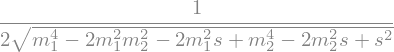

In [ ]:
print("flux factor  1/(2*sqrt(lambda(s,m1^2,m2^2))):")
display(kin.flux_factor())

## 2. The QED benchmark: $e^+e^-\to\mu^+\mu^-$ through one photon (Tier 1)

`feynlag.pheno.diagrams` builds the amplitude explicitly — open fermion
`SpinorChain`s joined by a `BosonPropagator` inside a `Diagram` — rather than writing
down an already-squared closed form the way the 1→2 decay engine does. That is what
makes attaching a *propagator*, and eventually a *second diagram*, possible at all.
`ffv_s_channel_squared` is the worked assembler for one fermion pair annihilating
into another through one s-channel vector.

In [ ]:
m, e = sp.symbols('m e', positive=True)
kin_qed = TwoToTwoKinematics(0, 0, m, m)
m2_qed = ffv_s_channel_squared(e, e, e, e, kin_qed, mediator_mass=0)

# display-only symbols for the closed-form check -- note kin.t is `real=True`,
# not `positive=True` (it's negative throughout the physical region), so this
# must match that exactly or the substitution below silently fails to bite.
s_sym, t_sym = sp.Symbol('s', positive=True), sp.Symbol('t', real=True)
m2_display = m2_qed.subs(kin_qed.s, s_sym).subs(kin_qed.t, t_sym)
u = 2 * m**2 - s_sym - t_sym
textbook = 8 * e**4 / s_sym**2 * ((t_sym - m**2)**2 + (u - m**2)**2 + 2 * m**2 * s_sym)
print("matches the textbook closed form:", sp.simplify(sp.expand(m2_display - textbook)) == 0)

# cross_section integrates over kin_qed.t itself -- feed it the UNsubstituted
# m2_qed, not the display version above (whose kin_qed.t is already gone).
electron = ExternalState('e', 0, sp.Rational(1, 2))
sigma_qed = sp.simplify(cross_section(m2_qed, kin_qed, (electron, electron)))
beta = sp.sqrt(1 - 4 * m**2 / kin_qed.s)
alpha = e**2 / (4 * sp.pi)
peskin = (4 * sp.pi * alpha**2 / (3 * kin_qed.s)) * beta * (3 - beta**2) / 2
print("matches Peskin & Schroeder closed form:", sp.simplify(sp.expand(sigma_qed - peskin)) == 0)

matches the textbook closed form: True


matches Peskin & Schroeder closed form: True


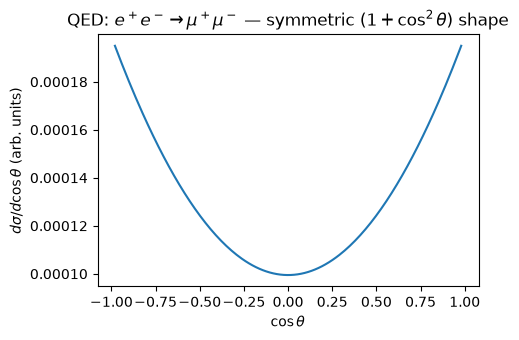

In [ ]:
# dsigma/dcos(theta) for the massless case, plotted
kin_massless = TwoToTwoKinematics(0, 0, 0, 0)
m2_massless = ffv_s_channel_squared(e, e, e, e, kin_massless, mediator_mass=0)
dsdcos_qed = differential_cross_section(m2_massless, kin_massless, (electron, electron),
                                        variable="cos")
cosv, s_num = sp.symbols('cos s', real=True)
dsdcos_qed = dsdcos_qed.subs(kin_massless.t, kin_massless.t_of_cos(cosv)).subs(kin_massless.s, s_num)
f_qed = sp.lambdify((cosv,), dsdcos_qed.subs({e: 1, s_num: 100}), 'numpy')

xs = np.linspace(-0.98, 0.98, 200)
plt.figure(figsize=(5, 3.5))
plt.plot(xs, f_qed(xs))
plt.xlabel(r"$\cos\theta$"); plt.ylabel(r"$d\sigma/d\cos\theta$ (arb. units)")
plt.title(r"QED: $e^+e^-\to\mu^+\mu^-$ — symmetric $(1+\cos^2\theta)$ shape")
plt.tight_layout(); plt.show()

The QED shape is symmetric under $\cos\theta\to-\cos\theta$ — as forward as it is
backward. That symmetry is about to break.

## 3. Why $\gamma_5$ survives for 2→2 but never did for a decay

Every trace in this library that involves a chiral projector $P_{L,R}=(1\mp\gamma_5)/2$
splits as

$$\mathrm{Tr}[X\,P_{L,R}] = \tfrac12\mathrm{Tr}[X] \mp \tfrac12\mathrm{Tr}[X\gamma_5].$$

The second term is a totally antisymmetric $\varepsilon^{abcd}$ tensor contracted with
whatever four indices $X$ supplies. $\varepsilon$ needs **four independent** vectors to
be non-zero at all (any repeated or linearly-dependent index kills it by
antisymmetry).

- A **1→2 decay** supplies only $p_1,p_2$ — two independent momenta ($P=p_1+p_2$ isn't
  a third) — so the term is *always* exactly zero. This is what
  `feynlag.pheno.lorentz.reduce_projectors` proves and relies on for every width this
  library has ever computed.
- A **2→2 process** has $k_1,k_2,k_3$ independent ($k_4=k_1+k_2-k_3$ is not a fourth) —
  **three** independent momenta. That is not yet four on its own, but when **two**
  separate chiral fermion currents meet at one propagator, each contributes its own
  momentum pair to a *different* $\varepsilon$, and the product of the two — the
  cross-chain $\varepsilon\cdot\varepsilon$ term — is generically **non-zero**. That
  product is exactly the forward–backward asymmetry.

`reduce_projectors` was tightened from "provably zero for $\le3$ momenta" to
"$\le2$" for exactly this reason (a 2→2 process was silently passing under the old,
looser threshold). The chain-level 2→2 engine in `pheno/diagrams.py` no longer calls
`reduce_projectors` at all — it computes the ε term for real instead.

## 4. The ε·ε algebra: two identities, both signs *derived*

`feynlag.pheno.epsilon` is the one module with $\varepsilon$-tensor knowledge.
SymPy's own Clifford-algebra engine (`sympy.physics.hep.gamma_matrices`) has **no**
$\gamma_5$ object and no ε-aware trace, so both identities below are built from
scratch rather than looked up — and, following this library's rule that a sign is
*derived* from the explicit Dirac representation rather than quoted from a textbook
(the same discipline `feynlag.dirac.majorana_symmetry_sign` uses), so are $\kappa$ and
$s_{\det}$ below.

**Identity 1** — $\mathrm{Tr}[\gamma^a\gamma^b\gamma^c\gamma^d\gamma_5]=\kappa\,\varepsilon^{abcd}$:

In [ ]:
kappa = gamma5_trace_coefficient()
print("kappa =", kappa, " (derived from the literal g0 g1 g2 g3 g5 matrix trace)")

kappa = -4*I  (derived from the literal g0 g1 g2 g3 g5 matrix trace)


**Identity 2** — $\varepsilon^{a\ldots}\varepsilon^{b\ldots}=s_{\det}\cdot\det[g^{a_ib_j}]$,
a genuine Gram-determinant computation:

In [ ]:
s_det = epsilon_product_sign()
print("s_det =", s_det, " (derived against the (+,-,-,-) metric)")

s_det = -1  (derived against the (+,-,-,-) metric)


`epsilon_pair_tensor` expands identity 2 as 24 signed products of four metrics, with
every free Lorentz index left **open** — no partial-contraction identity needed, and
the all-momentum case reduces on its own to $-\det[p_i\cdot p'_j]$. The one thing left
to check before this can be used at all: does a 2→2 diagram's own four momenta make
that Gram determinant vanish, so the *single*-ε cross terms (one chain's ε piece times
the other chain's ordinary trace) are provably zero?

In [ ]:
heads = [kin.k1, kin.k2, kin.k3, kin.k4]     # kin from section 1, symbolic masses
det = sp.simplify(gram_determinant(heads, kin.dot))
print("Gram determinant of the four external momenta:", det)
print("-> every single-ε cross term is provably zero for ANY 2->2 diagram")

Gram determinant of the four external momenta: 0
-> every single-ε cross term is provably zero for ANY 2->2 diagram


That is `feynlag.pheno.epsilon.assert_epsilon_single_vanishes`'s job: prove this
*computationally*, from the diagram's own `kin.dot` table, every time — not assume it
from a momentum count that would need re-deriving for a future topology.

With both identities in hand, `Amplitude.squared` no longer has to refuse a
chiral-on-both-vertices diagram: it adds the computed $\varepsilon\cdot\varepsilon$
piece to the ordinary (non-ε) piece before the **one**
`contract_to_dots` call the rest of the engine already relies on.

## 5. $e^+e^-\to\mu^+\mu^-$ through the Z: extracting real couplings from the Lagrangian

Rather than typing in the textbook $g_L=T_3-Q\sin^2\theta_W$ formula, this section
builds the SM electroweak gauge sector with two lepton generations and pulls the
*actual* $Z\bar ff$ vertex — `g_left`/`g_right` — straight out of the Lagrangian, the
same way `DecayCalculator` does internally for 1→2 widths. See
`examples/ee_to_ff.py` for the standalone script this section is drawn from.

In [ ]:
GW, G1, VEV, MH, MZ = 0.6535, 0.3580, 246.0, 125.25, 91.1876

def build_model():
    ew = electroweak_scaffold(gw=GW, g1=G1, v=VEV, mh=MH)
    SU2L, U1Y = ew.SU2L, ew.U1Y
    i = sp.Symbol("i", integer=True)

    def doublet(name, comps):
        return WeylFermion(name, reps={SU2L: 2, U1Y: -sp.Rational(1, 2)},
                           chirality="L", nflavors=1, component_names=comps)

    def singlet(name, comp):
        return WeylFermion(name, reps={U1Y: -1}, chirality="R", nflavors=1,
                           component_names=[comp])

    Le, eR = doublet("Le", ["nueL", "eL"]), singlet("eR", "eR")
    Lmu, muR = doublet("Lmu", ["numuL", "muL"]), singlet("muR", "muR")

    L = Lagrangian()
    ew.add_higgs(L)
    for f in (Le, eR, Lmu, muR):
        L.add(fermion_gauge_current(f, i), sector="gauge")

    model = Model("SM_ee_mumu", gauge_groups=ew.gauge_groups,
                  fields=ew.fields + [Le, eR, Lmu, muR],
                  parameters=ew.parameters, lagrangian=L)
    model.solve_tadpoles([ew.mu2])
    phys = to_physical_basis(model, ew)

    eL, eLb = Le.components[1], Le.bar_components[1]
    eRc, eRb = eR.components[0], eR.bar_components[0]
    muL, muLb = Lmu.components[1], Lmu.bar_components[1]
    muRc, muRb = muR.components[0], muR.bar_components[0]
    e_sym, ebar_sym, mu_sym, mubar_sym = sp.symbols("e ebar mu mubar")
    particle_map = {eL[i]: e_sym, eRc[i]: e_sym, eLb[i]: ebar_sym, eRb[i]: ebar_sym,
                    muL[i]: mu_sym, muRc[i]: mu_sym, muLb[i]: mubar_sym, muRb[i]: mubar_sym}
    return dict(model=model, conjugate_map=phys.cmap, Z=phys.Z,
                e=e_sym, ebar=ebar_sym, mu=mu_sym, mubar=mubar_sym,
                particle_map=particle_map, gw=ew.gw, g1=ew.g1)


def z_coupling(built, particle, antiparticle):
    vertices = collect_decay_vertices(built["model"], [built["Z"]], fermion_sectors=("gauge",),
                                      conjugate_map=built["conjugate_map"],
                                      particle_map=built["particle_map"])
    for v in vertices:
        if v.vertex_type == "FFV" and set(v.particles[:2]) == {particle, antiparticle}:
            return v.g_left, v.g_right
    raise RuntimeError("vertex not found")


built = build_model()
gL, gR = z_coupling(built, built["e"], built["ebar"])
hL, hR = z_coupling(built, built["mu"], built["mubar"])
couplings_num = {built["gw"].s: GW, built["g1"].s: G1}
gL, gR, hL, hR = (c.subs(couplings_num) for c in (gL, gR, hL, hR))
print(f"g_L = {complex(gL):.4f},  g_R = {complex(gR):.4f}   (electron; g_L != g_R -- chiral!)")

g_L = 0.0000-0.2006j,  g_R = 0.0000+0.1720j   (electron; g_L != g_R -- chiral!)


`g_L \ne g_R`: the electron's Z coupling is genuinely chiral (the weak interaction
distinguishes left- from right-handed fermions), unlike the vector QED photon coupling
above. This is exactly the case Tier 1 could only refuse.

In [ ]:
kin_z = TwoToTwoKinematics(0, 0, 0, 0)
mZ_sym = sp.Symbol('m_Z', positive=True)
m2_z = ffv_s_channel_squared(gL, gR, hL, hR, kin_z, mediator_mass=mZ_sym)
print("Sigma|M|^2 computed without raising -- this is the Tier-2 result.")

afb_expr = forward_backward_asymmetry(m2_z, kin_z)
Ae = (gL**2 - gR**2) / (gL**2 + gR**2)
Af = (hL**2 - hR**2) / (hL**2 + hR**2)
lep_formula = sp.Rational(3, 4) * Ae * Af
# A_FB is independent of s and m_Z -- the propagator denominator is a
# cosθ-independent common factor that cancels exactly in the sigma_F/sigma_B
# ratio (proved symbolically, with mediator_mass=0, in
# test_z_only_forward_backward_asymmetry_is_three_quarters_Ae_Af). With a
# genuine m_Z symbol and float (not exact-rational) couplings, sympy's
# `simplify` does not always spot that cancellation, so this evaluates at one
# concrete benchmark point rather than asserting it symbolically here.
afb_num = complex(afb_expr.subs({kin_z.s: 200.0**2, mZ_sym: MZ}))
lep_num = complex(lep_formula)
print("A_FB matches (3/4) A_e A_f  [LEPEWWG06 Eq. 1.66]:", abs(afb_num - lep_num) < 1e-9)
print("A_FB numeric value:", round(afb_num.real, 5))

Sigma|M|^2 computed without raising -- this is the Tier-2 result.


A_FB matches (3/4) A_e A_f  [LEPEWWG06 Eq. 1.66]: True
A_FB numeric value: 0.01743


$A_{FB}=\tfrac34A_eA_f$ is Eq. (1.66) of the LEP Electroweak Working Group's combined
Z-pole report [ALEPH/DELPHI/L3/OPAL/SLD, Phys. Rept. 427 (2006) 257,
arXiv:hep-ex/0509008] — the actual measured LEP asymmetry formula, reproduced here
from first principles through this library's Dirac-trace engine.

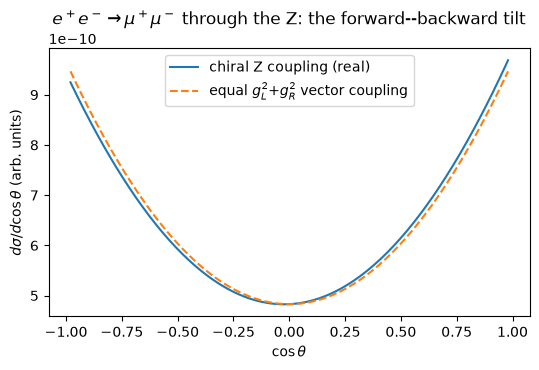

In [ ]:
# dsigma/dcos(theta): chiral (Z) vs. an equal-|gL|^2+|gR|^2 "vector-like" coupling
dsdcos_z = differential_cross_section(m2_z, kin_z, (electron, electron), variable="cos")
dsdcos_z = dsdcos_z.subs(kin_z.t, kin_z.t_of_cos(cosv)).subs(kin_z.s, s_num)
f_z = sp.lambdify((cosv,), dsdcos_z.subs({mZ_sym: MZ, s_num: 200.0**2}), 'numpy')

ge, hf = sp.sqrt((gL**2 + gR**2) / 2), sp.sqrt((hL**2 + hR**2) / 2)
m2_vec = ffv_s_channel_squared(ge, ge, hf, hf, kin_z, mediator_mass=mZ_sym)
dsdcos_vec = differential_cross_section(m2_vec, kin_z, (electron, electron), variable="cos")
dsdcos_vec = dsdcos_vec.subs(kin_z.t, kin_z.t_of_cos(cosv)).subs(kin_z.s, s_num)
f_vec = sp.lambdify((cosv,), dsdcos_vec.subs({mZ_sym: MZ, s_num: 200.0**2}), 'numpy')

xs = np.linspace(-0.98, 0.98, 200)
plt.figure(figsize=(5.5, 3.8))
plt.plot(xs, f_z(xs), label="chiral Z coupling (real)")
plt.plot(xs, f_vec(xs), '--', label=r"equal $g_L^2{+}g_R^2$ vector coupling")
plt.xlabel(r"$\cos\theta$"); plt.ylabel(r"$d\sigma/d\cos\theta$ (arb. units)")
plt.title(r"$e^+e^-\to\mu^+\mu^-$ through the Z: the forward--backward tilt")
plt.legend(); plt.tight_layout(); plt.show()

The chiral (solid) curve tilts toward forward scattering ($\cos\theta>0$) relative to
the symmetric vector-coupling (dashed) curve — the ε term's visible signature. The two
curves enclose the **same area**: `test_z_only_total_cross_section_is_epsilon_independent`
pins that the ε term is odd in $\cos\theta$ and integrates away over the full range, so
the *total* cross section only depends on $g_L^2+g_R^2$. $A_{FB}$ is an angular
observable only — Tier 1's photon-only 2.322 pb benchmark cross section is unaffected
by any of this landing.

## 6. Where this leaves the roadmap

| tier | status | what it adds |
|---|---|---|
| 1 | ✅ shipped | kinematics, one diagram, no interference — the QED benchmark above |
| 2 | ✅ shipped | the ε (γ₅) algebra — the Z-only chiral result and $A_{FB}$ above |
| 3 | not started | γ/Z **interference** — the full 2.7878 pb MadGraph benchmark |
| 4 | not started | derivative couplings — $e^+e^-\to W^+W^-$, gauge cancellation |
| 5 | not started | coloured/hadronic 2→2 (parton level, no PDFs) |

See `docs/manual/scattering_roadmap.md` for the full tiered plan, and
`tests/test_scattering.py` for everything this notebook's numbers are pinned against.